# Bidirectional Predictive Coding on CIFAR-10 with a VGG-5 CNN

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thebuckleylab/jpc/blob/main/examples/bidirectional_pc_cifar_cnn.ipynb)

This notebook is a convolutional variant of the [bidirectional predictive coding](bidirectional_pc.ipynb) example (BPC; [Olivers et al., 2025](https://arxiv.org/abs/2505.23415)). Instead of an MLP on MNIST, we train a bidirectional PC network with a **VGG-5 style CNN on CIFAR-10** that can both generate and classify natural images, matching the architecture used for bPC in Oliviers et al. (2025, Appendix I).

The generator (top-down) is a 5-layer transposed-convolutional network that maps a one-hot label to an image, and the amortiser (bottom-up) is a 5-layer convolutional network (VGG-5: 4 conv + MaxPool stages + 1 linear classifier) that maps the image back to the label. Inference dynamics are driven by both top-down and bottom-up prediction errors at every hidden layer, exactly as in the MLP example.

Following the paper, the forward (generative) energies are heavily downweighted by $\alpha_{\text{gen}} = 10^{-5}$ so that the network is biased toward classification while still supporting reconstruction.

In [ ]:
%%capture
!pip install torch==2.3.1
!pip install torchvision==0.18.1
!pip install matplotlib==3.0.0

In [1]:
import jpc

import jax
import jax.numpy as jnp
import equinox as eqx
import equinox.nn as nn
import optax

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')  # ignore warnings

## Hyperparameters

The VGG-5 architecture has **5 layers** (4 conv stages + 1 linear layer) with channels `[128, 256, 512, 512]` and works at the following spatial resolutions:

| Activity | Shape |
| --- | --- |
| `activities[0]` | `(512, 2, 2)` |
| `activities[1]` | `(512, 4, 4)` |
| `activities[2]` | `(256, 8, 8)` |
| `activities[3]` | `(128, 16, 16)` |
| `activities[4]` (= image prediction) | `(3, 32, 32)` |

Images are normalised to the `[-1, 1]` range so that the input distribution matches the generator's `tanh` output.

In [2]:
SEED = 0

N_CLASSES = 10
IMG_CHANNELS = 3
IMG_SIZE = 32
ACT_FN = "gelu"
USE_BIAS = True

ACTIVITY_LR = 1e-1
ACTIVITY_MOMENTUM = 0.9
PARAM_LR = 1e-3
BATCH_SIZE = 64
TEST_EVERY = 50
N_TRAIN_ITERS = 300

# inference iterations per batch (deeper nets need more)
N_INFERENCE_STEPS = 8

## Dataset

Some utils to fetch CIFAR-10. Unlike the MNIST example, images are **not** flattened — they are kept as `(3, 32, 32)` tensors so that they can be processed by convolutional layers.

In [3]:
# Normalise to [-1, 1] so the input range matches the generator's tanh output
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)
CIFAR_CLASSES = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)


def get_cifar_loaders(batch_size):
    train_data = CIFAR10(train=True, normalise=True)
    test_data = CIFAR10(train=False, normalise=True)
    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    return train_loader, test_loader


class CIFAR10(datasets.CIFAR10):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD)
            ])
        else:
            transform = transforms.Compose([transforms.ToTensor()])
        super().__init__(save_dir, download=True, train=train, transform=transform)

    def __getitem__(self, index):
        img, label = super().__getitem__(index)  # img has shape (3, 32, 32)
        label = one_hot(label)
        return img, label


def one_hot(labels, n_classes=10):
    arr = torch.eye(n_classes)
    return arr[labels]


def plot_cifar_imgs(imgs, labels, n_imgs=10):
    mean = np.array(CIFAR_MEAN).reshape(3, 1, 1)
    std = np.array(CIFAR_STD).reshape(3, 1, 1)
    imgs = np.asarray(imgs) * std + mean
    imgs = np.clip(imgs, 0.0, 1.0)

    plt.figure(figsize=(20, 2))
    for i in range(n_imgs):
        plt.subplot(1, n_imgs, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        # (3, 32, 32) -> (32, 32, 3)
        plt.imshow(np.transpose(imgs[i], (1, 2, 0)))
        plt.xlabel(CIFAR_CLASSES[int(jnp.argmax(labels, axis=1)[i])])
    plt.show()

## CNN model

We use a **VGG-5** architecture following Oliviers et al. (2025, Appendix I). The amortiser is the standard VGG-5 with 4 `Conv + MaxPool` stages (channels 128, 256, 512, 512) followed by a flatten + linear classifier. The generator mirrors this: a linear projection reshaped to `(512, 2, 2)` followed by 4 `ConvTranspose2d` stages ending in a `tanh` output.

Both networks are built as lists of `equinox` modules, matching what [`jpc.make_mlp()`](https://thebuckleylab.github.io/jpc/api/Utils/#jpc.make_mlp) returns — the bPC update functions don't care whether each layer is fully-connected or convolutional.

Following the MLP convention in `jpc.make_mlp`, every layer applies the activation function **before** the linear/conv transformation. The first layer of each network uses an Identity activation so that the raw label / image is not clipped by an activation.

The amortiser is built image $\rightarrow$ label and then reversed with `[::-1]`, so that, after reversal, `amortiser[l]` is the "dual" of `generator[l]` — it maps between the same two activity shapes, but in the opposite direction.

In [4]:
class Reshape(eqx.Module):
    shape: tuple = eqx.field(static=True)

    def __call__(self, x, *, key=None):
        return x.reshape(self.shape)


class Flatten(eqx.Module):
    def __call__(self, x, *, key=None):
        return x.reshape(-1)


def make_cnn_generator(key, n_classes, img_channels, use_bias, act_fn):
    keys = jax.random.split(key, 5)
    act = jpc.get_act_fn(act_fn)
    return [
        # layer 0: label (10) -> (512, 2, 2)
        nn.Sequential([
            nn.Lambda(nn.Identity()),
            nn.Linear(n_classes, 512 * 2 * 2, use_bias=use_bias, key=keys[0]),
            Reshape((512, 2, 2))
        ]),
        # layer 1: (512, 2, 2) -> (512, 4, 4)
        nn.Sequential([
            nn.Lambda(act),
            nn.ConvTranspose2d(
                in_channels=512, out_channels=512,
                kernel_size=3, stride=2, padding=1, output_padding=1,
                use_bias=use_bias, key=keys[1]
            )
        ]),
        # layer 2: (512, 4, 4) -> (256, 8, 8)
        nn.Sequential([
            nn.Lambda(act),
            nn.ConvTranspose2d(
                in_channels=512, out_channels=256,
                kernel_size=3, stride=2, padding=1, output_padding=1,
                use_bias=use_bias, key=keys[2]
            )
        ]),
        # layer 3: (256, 8, 8) -> (128, 16, 16)
        nn.Sequential([
            nn.Lambda(act),
            nn.ConvTranspose2d(
                in_channels=256, out_channels=128,
                kernel_size=3, stride=2, padding=1, output_padding=1,
                use_bias=use_bias, key=keys[3]
            )
        ]),
        # layer 4: (128, 16, 16) -> (3, 32, 32), tanh so output lives in [-1, 1]
        nn.Sequential([
            nn.Lambda(act),
            nn.ConvTranspose2d(
                in_channels=128, out_channels=img_channels,
                kernel_size=3, stride=2, padding=1, output_padding=1,
                use_bias=use_bias, key=keys[4]
            ),
            nn.Lambda(jnp.tanh)
        ]),
    ]


def make_cnn_amortiser(key, n_classes, img_channels, use_bias, act_fn):
    keys = jax.random.split(key, 5)
    act = jpc.get_act_fn(act_fn)

    # Built in image -> label order, then reversed below.
    built = [
        # (3, 32, 32) -> (128, 16, 16)
        nn.Sequential([
            nn.Lambda(nn.Identity()),
            nn.Conv2d(
                in_channels=img_channels, out_channels=128,
                kernel_size=3, stride=1, padding=1,
                use_bias=use_bias, key=keys[0]
            ),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]),
        # (128, 16, 16) -> (256, 8, 8)
        nn.Sequential([
            nn.Lambda(act),
            nn.Conv2d(
                in_channels=128, out_channels=256,
                kernel_size=3, stride=1, padding=1,
                use_bias=use_bias, key=keys[1]
            ),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]),
        # (256, 8, 8) -> (512, 4, 4)
        nn.Sequential([
            nn.Lambda(act),
            nn.Conv2d(
                in_channels=256, out_channels=512,
                kernel_size=3, stride=1, padding=1,
                use_bias=use_bias, key=keys[2]
            ),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]),
        # (512, 4, 4) -> (512, 2, 2)
        nn.Sequential([
            nn.Lambda(act),
            nn.Conv2d(
                in_channels=512, out_channels=512,
                kernel_size=3, stride=1, padding=1,
                use_bias=use_bias, key=keys[3]
            ),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]),
        # (512, 2, 2) -> label (10)
        nn.Sequential([
            nn.Lambda(act),
            Flatten(),
            nn.Linear(512 * 2 * 2, n_classes, use_bias=use_bias, key=keys[4])
        ]),
    ]
    return built[::-1]

## Train and test

A note on activity initialisation: following the amortised-inference idea from the paper, we initialise activities by running the **amortiser forward on the image**. Because the CNN generator and amortiser have asymmetric shapes (their spatial/channel sizes grow in opposite directions), the amortiser's per-layer outputs appear in reversed order compared to the generator's activities — so we reverse that list (and drop its final label prediction) before assigning it as the initial activities, then append the input image as the last (unused) padding slot.

The activity optimiser uses SGD with Nesterov momentum; plain gradient descent converges too slowly at this depth.

In [5]:
def init_activities_bottom_up(amortiser, img_batch):
    """Initialise activities by running the amortiser forward on the image.

    ``amortiser`` is stored in label-to-image order (it was built image-to-label
    then reversed with ``[::-1]``), so ``amortiser[::-1]`` is the image-to-label
    forward pass. Its per-layer outputs are in the reverse order of the
    generator's activities, so we reverse them before using them. The final
    element of the forward pass is the label prediction, which we drop; we then
    append the image itself as the final (unused) activity slot expected by the
    bPC energy function.
    """
    ffwd = jpc.init_activities_with_ffwd(
        model=amortiser[::-1],
        input=img_batch
    )
    # ffwd: [image-adjacent hidden, ..., label-adjacent hidden, label prediction]
    # want:  [label-adjacent hidden, ..., image-adjacent hidden, image]
    reversed_hidden = list(reversed(ffwd))[1:]
    return reversed_hidden + [img_batch]


def evaluate(generator, amortiser, test_loader):
    amort_accs = 0.
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_accs += jpc.compute_accuracy(label_batch, preds)

    img_preds = jpc.init_activities_with_ffwd(
        model=generator,
        input=label_batch
    )[-1]

    return (
        amort_accs / len(test_loader),
        label_batch,
        img_preds
    )


def train(
      seed,
      n_classes,
      img_channels,
      use_bias,
      act_fn,
      batch_size,
      activity_lr,
      activity_momentum,
      param_lr,
      test_every,
      n_train_iters,
      n_inference_steps,
      forward_energy_weight=1e-5
):
    key = jax.random.PRNGKey(seed)
    gen_key, amort_key = jax.random.split(key, 2)

    generator = make_cnn_generator(
        gen_key,
        n_classes=n_classes,
        img_channels=img_channels,
        use_bias=use_bias,
        act_fn=act_fn
    )
    amortiser = make_cnn_amortiser(
        amort_key,
        n_classes=n_classes,
        img_channels=img_channels,
        use_bias=use_bias,
        act_fn=act_fn
    )

    # optimisers
    activity_optim = optax.sgd(
        activity_lr, momentum=activity_momentum, nesterov=True
    )
    gen_optim = optax.adam(param_lr)
    amort_optim = optax.adam(param_lr)

    gen_opt_state = gen_optim.init(eqx.filter(generator, eqx.is_array))
    amort_opt_state = amort_optim.init(eqx.filter(amortiser, eqx.is_array))

    # data
    train_loader, test_loader = get_cifar_loaders(batch_size)

    for iter, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        # discriminative (amortiser) forward pass -- used for monitoring
        amort_preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_loss = jpc.mse_loss(
            amort_preds.reshape(batch_size, -1),
            label_batch.reshape(batch_size, -1)
        )

        # generative (generator) forward pass -- used for monitoring
        gen_preds = jpc.init_activities_with_ffwd(
            model=generator,
            input=label_batch
        )[-1]
        gen_loss = jpc.mse_loss(
            gen_preds.reshape(batch_size, -1),
            img_batch.reshape(batch_size, -1)
        )

        # bottom-up initialisation of activities (amortised inference)
        activities = init_activities_bottom_up(amortiser, img_batch)
        activity_opt_state = activity_optim.init(activities)

        # inference
        for _ in range(n_inference_steps):
            activity_update_result = jpc.update_bpc_activities(
                top_down_model=generator,
                bottom_up_model=amortiser,
                activities=activities,
                optim=activity_optim,
                opt_state=activity_opt_state,
                output=img_batch,
                input=label_batch,
                forward_energy_weight=forward_energy_weight
            )
            activities = activity_update_result["activities"]
            activity_opt_state = activity_update_result["opt_state"]

        # learning
        param_update_result = jpc.update_bpc_params(
            top_down_model=generator,
            bottom_up_model=amortiser,
            activities=activities,
            top_down_optim=gen_optim,
            bottom_up_optim=amort_optim,
            top_down_opt_state=gen_opt_state,
            bottom_up_opt_state=amort_opt_state,
            output=img_batch,
            input=label_batch,
            forward_energy_weight=forward_energy_weight
        )
        generator, amortiser = param_update_result["models"]
        gen_opt_state, amort_opt_state = param_update_result["opt_states"]

        if ((iter + 1) % test_every) == 0:
            amort_acc, label_batch, img_preds = evaluate(
                generator,
                amortiser,
                test_loader
            )
            print(
                f"Iter {iter+1}, gen loss={gen_loss:4f}, "
                f"amort loss={amort_loss:4f}, "
                f"avg amort test accuracy={amort_acc:4f}"
            )

            if (iter + 1) >= n_train_iters:
                break

    plot_cifar_imgs(img_preds, label_batch)

## Run

Iter 50, gen loss=420.141235, amort loss=0.394653, avg amort test accuracy=37.069309
Iter 100, gen loss=392.916443, amort loss=0.397735, avg amort test accuracy=42.027245
Iter 150, gen loss=395.317017, amort loss=0.366167, avg amort test accuracy=41.927082
Iter 200, gen loss=415.195435, amort loss=0.390046, avg amort test accuracy=48.717949
Iter 250, gen loss=379.847473, amort loss=0.338475, avg amort test accuracy=46.674679
Iter 300, gen loss=390.182617, amort loss=0.383663, avg amort test accuracy=47.345753


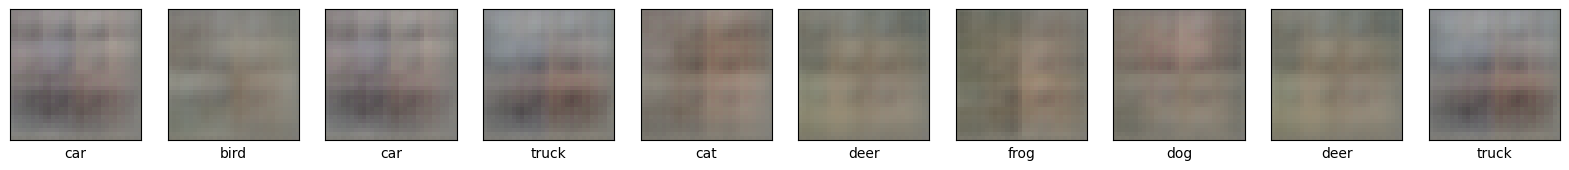

In [6]:
train(
    seed=SEED,
    n_classes=N_CLASSES,
    img_channels=IMG_CHANNELS,
    use_bias=USE_BIAS,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    activity_lr=ACTIVITY_LR,
    activity_momentum=ACTIVITY_MOMENTUM,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    n_inference_steps=N_INFERENCE_STEPS
)

The run above uses the paper's VGG-5 setting of $\alpha_{\text{gen}} = 10^{-5}$, which biases the network toward classification. For comparison, we can run with equal weighting ($\alpha_{\text{gen}} = 1$) — this trades some classification accuracy for better reconstruction of the CIFAR images.

Iter 50, gen loss=386.204071, amort loss=0.448618, avg amort test accuracy=14.733574
Iter 100, gen loss=444.923370, amort loss=0.456913, avg amort test accuracy=16.636618
Iter 150, gen loss=795.602539, amort loss=0.745794, avg amort test accuracy=12.730369
Iter 200, gen loss=583.000244, amort loss=0.834059, avg amort test accuracy=12.319712
Iter 250, gen loss=843.988770, amort loss=0.600712, avg amort test accuracy=13.070913
Iter 300, gen loss=1191.485840, amort loss=1.216216, avg amort test accuracy=9.985977


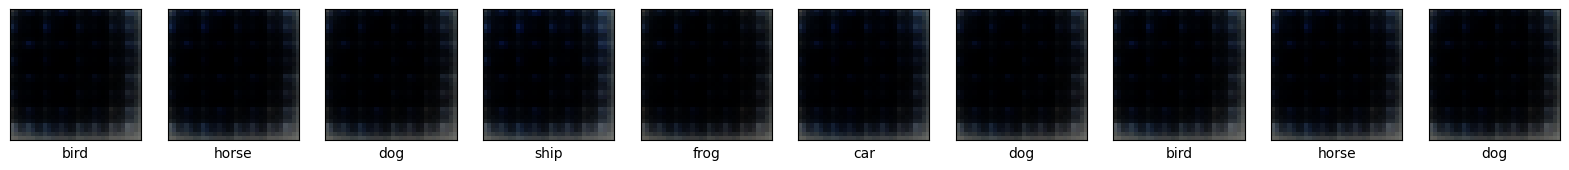

In [7]:
train(
    seed=SEED,
    n_classes=N_CLASSES,
    img_channels=IMG_CHANNELS,
    use_bias=USE_BIAS,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    activity_lr=ACTIVITY_LR,
    activity_momentum=ACTIVITY_MOMENTUM,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    n_inference_steps=N_INFERENCE_STEPS,
    forward_energy_weight=1.0
)